# Simple Hybrid System

This tutorial introduces hybrid co-simulation with a single zero-crossing event. We build a minimal system with one event source and one event listener to show how events are detected, localized, and dispatched.

![System Diagram](figures/simple_hybrid_system.svg)


## Overview

Hybrid systems combine continuous dynamics with discrete events. In SysSimX, events are detected using **event indicators** (zero-crossing functions) and handled by the Hybrid algorithm with event localization and rollback.

## Learning Goals

- Define a component with an event indicator (zero-crossing)
- Connect an event source to a listener using an `EventConnection`
- Run a hybrid simulation and visualize the event time


### Hybrid Algorithm

The core steps of the implemented hybrid algorithm are shown in the figure below.

- **Event Detection**: During each time step, the algorithm checks event indicators for zero-crossings. A zero-crossing indicates an event has occurred.
- **Event Localization**: If an event is detected, the algorithm performs a bisection search to find the exact time of the event within the time step. This procedure requires rolling back the simulation to the previous state and re-simulating with smaller time steps until the event time is localized within a specified tolerance.
- **Event Handling**: Using the event connections defined in the system, the algorithm dispatches the event to the appropriate listeners, which may trigger state changes or other events.

![Hybrid Algorithm](figures/hybrid_algorithm.svg)

## Prerequisites and Setup

We require the following packages:
- `syssimx`
- `numpy`
- `matplotlib`
- `graphviz` (for visualization)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import graphviz

from syssimx import CoSimComponent, System
from syssimx.core import PortSpec, PortType
from syssimx.system import EventConnection
from syssimx.viz.system_graph_visualizer import SystemGraphVisualizer

## Implementation

We define two components:

- **HybridSource**: Produces a linearly changing signal `x(t)` and emits an event when `x` crosses zero.
- **HybridListener**: Receives the event and flips its velocity instantaneously.

Event indicators require rollback support, so the source implements `snapshot_state` and `restore_state`.


### `HybridSource` Component

The source output evolves linearly:

$$x(t) = x_0 + v (t - t_0)$$

The event indicator is `x(t)`. When it crosses zero, an event is triggered.


In [2]:
class HybridSource(CoSimComponent):
    """Linear source with an event indicator at x = 0."""

    def __init__(self, name: str, x0: float = -1.0, v: float = 1.0, t0: float = 0.0):
        super().__init__(name, group="Source")
        self.x0 = x0
        self.v = v
        self.t0 = t0
        self.output_specs.update({
            "x": PortSpec(name="x", type=PortType.REAL, direction="out")
        })

    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0

    def _do_step_internal(self, t: float, dt: float) -> None:
        self.x = self.x0 + self.v * (t + dt - self.t0)

    def _update_output_states(self, t: float | None = None, event_names=None) -> None:
        self.outputs["x"].set(self.x, t=t)

    def snapshot_state(self):
        return {
            "t": self.t,
            "x": self.x,
            "x0": self.x0,
            "v": self.v,
            "t0": self.t0,
        }

    def restore_state(self, snapshot, t) -> None:
        self.t = t
        self.x = snapshot["x"]
        self.x0 = snapshot["x0"]
        self.v = snapshot["v"]
        self.t0 = snapshot["t0"]


### `HybridListener` Component

The listener reacts to the event by inverting its velocity. This is a discrete state change handled in `_handle_events_internal`.


In [3]:
class HybridListener(CoSimComponent):
    """Listener that flips velocity on event reception."""

    def __init__(self, name: str, x0: float = 0.0, v: float = 0.5, t0: float = 0.0):
        super().__init__(name, group="Listener")
        self.x0 = x0
        self.v = v
        self.t0 = t0

        self.input_specs.update({
            "v_invert": PortSpec(name="v_invert", type=PortType.EVENT, direction="in")
        })
        self.output_specs.update({
            "x": PortSpec(name="x", type=PortType.REAL, direction="out")
        })

    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0

    def _do_step_internal(self, t: float, dt: float) -> None:
        self.x = self.x0 + self.v * (t + dt - self.t0)

    def _update_output_states(self, t: float | None = None, event_names=None) -> None:
        self.outputs["x"].set(self.x, t=t)

    def _handle_events_internal(self, event_names, t) -> None:
        if "zero_crossing" in event_names:
            self.t0 = t
            self.x0 = self.x
            self.v = -self.v


## Instantiation of Components

We set the source to cross zero at `t = (2/3.0) s` so the event is easy to see.


In [4]:
source = HybridSource(name="Source", x0=-2/3, v=1.0)
listener = HybridListener(name="Listener", x0=0.0, v=0.5)

## Defining Event Connections

We register an event indicator on the source and connect it to the listener.

The indicator triggers on a **rising** zero-crossing (`direction=1`).


In [5]:
def zero_crossing_indicator(comp: HybridSource) -> float:
    return comp.x

source.add_event_indicator(name="zero_crossing", func=zero_crossing_indicator, direction=1)

event_conn = EventConnection(
    src_comp=source.name,
    src_port="zero_crossing",
    dst_comp=listener.name,
    dst_port=listener.input_specs["v_invert"].name,
)

## Creating the System

The hybrid algorithm is selected automatically when event indicators are present.


In [6]:
system = System(name="Simple Hybrid System")
system.add_component(source)
system.add_component(listener)
system.add_event_connection(event_conn)

system.initialize(t0=0.0)
print(f"Using algorithm: {system.algorithm.name}")
system.algorithm.record_internal_steps = True

Using algorithm: Hybrid-Algorithm


In [7]:
import logging

logging.basicConfig(
    level=logging.WARNING,  # keep third-party loggers quiet
    format="[%(module)s] %(levelname)s: %(message)s",
)
# Enable debug output for the syssimx package
logging.getLogger("syssimx").setLevel(logging.DEBUG)

## Visualizing the System Graph

Event connections are shown as dashed links in the system graph.


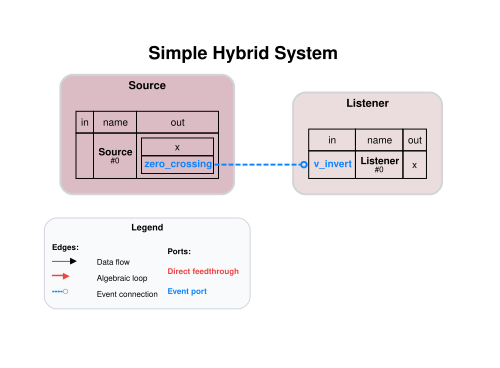

In [8]:
visualizer = SystemGraphVisualizer(system)
visualizer.visualize()

## Running the Simulation

We simulate for 1 second with a fixed time step. The Hybrid algorithm will localize the zero-crossing event.


In [9]:
t0 = 0.0
tf = 1.0
dt = 0.05

system.run(t0=t0, tf=tf, dt=dt)

[system] INFO: Starting simulation run from t=0.0 to t=1.0 with dt=0.05
[hybrid] INFO: ================================================================================
[hybrid] INFO: Event crossing in [0.650000, 0.700000]: Source.zero_crossing
[hybrid] DEBUG: Starting bisection for event localization ...
[hybrid] DEBUG: Indicators at left  (t=0.65000000): {'Source': {'zero_crossing': -0.016666666666666607}}
[hybrid] DEBUG: Indicators at right (t=0.70000000): {'Source': {'zero_crossing': 0.03333333333333344}}
[hybrid] DEBUG: Bisection iteration 1: interval [0.65000000, 0.70000000]
[hybrid] DEBUG: Bisection iteration 2: interval [0.65000000, 0.67500000]
[hybrid] DEBUG: Bisection iteration 3: interval [0.66250000, 0.67500000]
[hybrid] DEBUG: Bisection iteration 4: interval [0.66250000, 0.66875000]
[hybrid] DEBUG: Bisection iteration 5: interval [0.66562500, 0.66875000]
[hybrid] DEBUG: Bisection iteration 6: interval [0.66562500, 0.66718750]
[hybrid] DEBUG: Bisection iteration 7: interval 

## Retrieving History

We retrieve the component histories and the detected event time.


In [10]:
history = system.get_history()

t_src, data_src = history["Source"]
x_src = data_src["x"]

t_listener, data_listener = history["Listener"]
x_listener = data_listener["x"]

event_history = system.history.get_all_event_histories()
zero_crossings = event_history.get((source.name, "zero_crossing"), [])

event_time = zero_crossings[0].t if zero_crossings else None
print(f"Detected Events: {len(zero_crossings)}")
print(f"Event Name: {source.event_indicators['zero_crossing'].name}")
print(f"Event time: {event_time}")


Detected Events: 1
Event Name: zero_crossing
Event time: 0.6666671752929688


## Visualizing the Results

The source crosses zero once. The listener flips velocity at the event time, producing a kink in its trajectory.


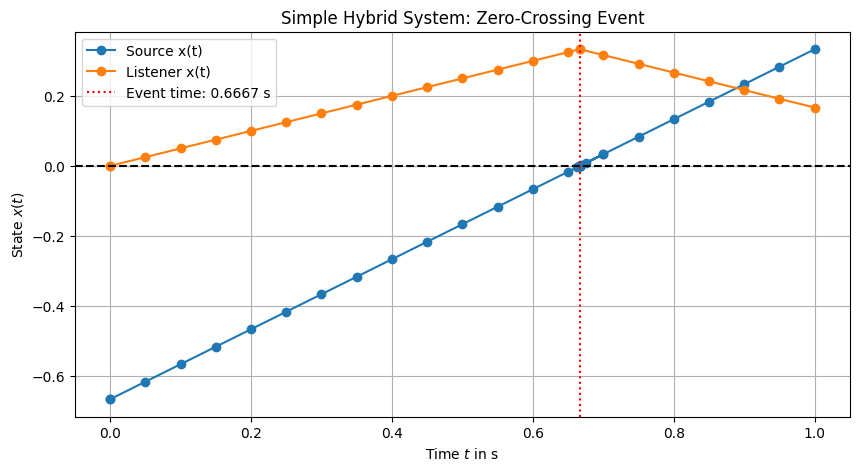

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(t_src, x_src, label="Source x(t)", marker="o", linestyle="-")
plt.plot(t_listener, x_listener, label="Listener x(t)", marker="o", linestyle="-")

if event_time is not None:
    plt.axvline(event_time, color="red", linestyle=":", label=f"Event time: {event_time:.4f} s")

plt.axhline(0, color="k", linestyle="--")
plt.title("Simple Hybrid System: Zero-Crossing Event")
plt.xlabel(r"Time $t$ in s")
plt.ylabel(r"State $x(t)$")
plt.grid()
plt.legend()
plt.show()


**Detailed View on Zero-Crossing Event**

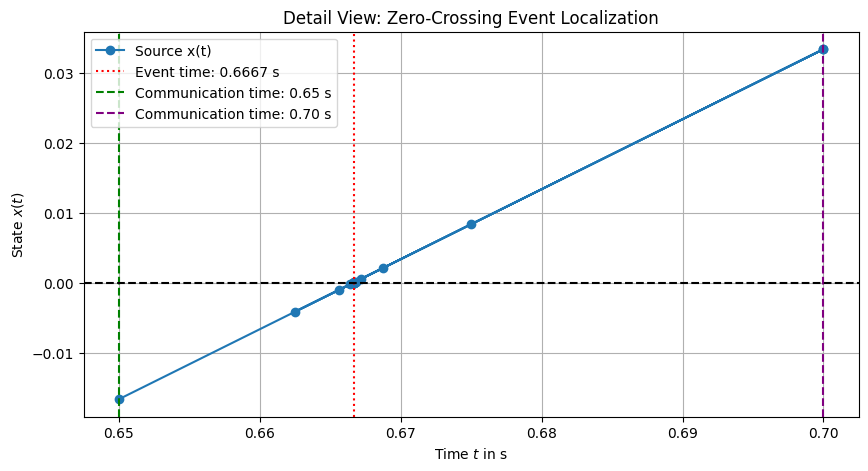

In [12]:
if event_time is None:
    raise RuntimeError("No event detected. Check indicator configuration.")

zoom_window = 0.05
mask = (t_src >= event_time - zoom_window) & (t_src <= event_time + zoom_window)

# Communication times around the event (based on dt)
t_comm_left = np.floor(event_time / dt) * dt
t_comm_right = t_comm_left + dt

plt.figure(figsize=(10, 5))
plt.plot(t_src[mask], x_src[mask], label="Source x(t)", marker="o", linestyle="-")
plt.axvline(event_time, color="red", linestyle=":", label=f"Event time: {event_time:.4f} s")
plt.axvline(t_comm_left, color="green", linestyle="--", label=f"Communication time: {t_comm_left:.2f} s")
plt.axvline(t_comm_right, color="purple", linestyle="--", label=f"Communication time: {t_comm_right:.2f} s")
plt.axhline(0, color="k", linestyle="--")
plt.title("Detail View: Zero-Crossing Event Localization")
plt.xlabel(r"Time $t$ in s")
plt.ylabel(r"State $x(t)$")
plt.grid()
plt.legend()
plt.show()

The figure above shows the source state around the zero-crossing event. The Hybrid algorithm localizes the event time, ensuring the trajectory reflects the instantaneous change.

The event is detected because the indicator changes sign between two communication points. The algorithm then bisects the interval between these points, rolling back as needed to converge on the event time within the specified tolerance.


## Conclusion

This example shows a minimal hybrid system with a single zero-crossing event.

SysSimX detects the event using an indicator function, localizes it with rollback, and dispatches it to the listener during simulation.
